In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import cv2
import mediapipe as mp
from tqdm import tqdm


In [2]:
import zipfile
import os

zip_path = "CCDEPLRL_MidtermsP2_Data.zip"
extract_path = "CCDEPLRL_MidtermsP2_Data"

# Make sure the output directory exists
os.makedirs(extract_path, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzip complete!")

Unzip complete!


In [5]:
SOURCE_DIR = "CCDEPLRL_MidtermsP2_Data/CCDEPLRL_MidtermsP2_Data"
OUTPUT_DIR = "CCDEPLRL_MidtermsP2_Data_Cropped"
IMG_SIZE = 128

# Initialize Mediapipe face detector
mp_face_detection = mp.solutions.face_detection
face_detector = mp_face_detection.FaceDetection(model_selection=1, min_detection_confidence=0.9)

# Prepare output directories
splits = ["Train", "Validation", "Test"]
for split in splits:
    for class_name in os.listdir(os.path.join(SOURCE_DIR, split)):
        os.makedirs(os.path.join(OUTPUT_DIR, split, class_name), exist_ok=True)

# Crop faces and save resized output
for split in splits:
    for class_name in os.listdir(os.path.join(SOURCE_DIR, split)):
        input_dir = os.path.join(SOURCE_DIR, split, class_name)
        output_dir = os.path.join(OUTPUT_DIR, split, class_name)

        for file in tqdm(os.listdir(input_dir), desc=f"Processing {split}/{class_name}"):
            file_path = os.path.join(input_dir, file)
            img = cv2.imread(file_path)
            if img is None:
                continue

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            result = face_detector.process(img_rgb)

            if result.detections:
                det = result.detections[0]
                bbox = det.location_data.relative_bounding_box
                h, w, _ = img.shape
                x = int(bbox.xmin * w)
                y = int(bbox.ymin * h)
                bw = int(bbox.width * w)
                bh = int(bbox.height * h)

                pad = 20
                x1 = max(x - pad, 0)
                y1 = max(y - pad, 0)
                x2 = min(x + bw + pad, w)
                y2 = min(y + bh + pad, h)

                face_crop = img[y1:y2, x1:x2]
                resized_crop = cv2.resize(face_crop, (IMG_SIZE, IMG_SIZE))
                out_path = os.path.join(output_dir, file)
                cv2.imwrite(out_path, resized_crop)


Processing Train/Blix:   0%|          | 0/137 [00:00<?, ?it/s]

Processing Test/Jessy: 100%|██████████| 40/40 [00:01<00:00, 28.09it/s]


In [50]:
img_height, img_width = 128, 128
batch_size = 64


In [7]:
base_path = "CCDEPLRL_MidtermsP2_Data_Cropped"

train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{base_path}/Train",
    image_size=(img_height, img_width),
    batch_size=batch_size
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{base_path}/Validation",
    image_size=(img_height, img_width),
    batch_size=batch_size
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{base_path}/Test",
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 558 files belonging to 4 classes.
Found 82 files belonging to 4 classes.
Found 155 files belonging to 4 classes.


In [51]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

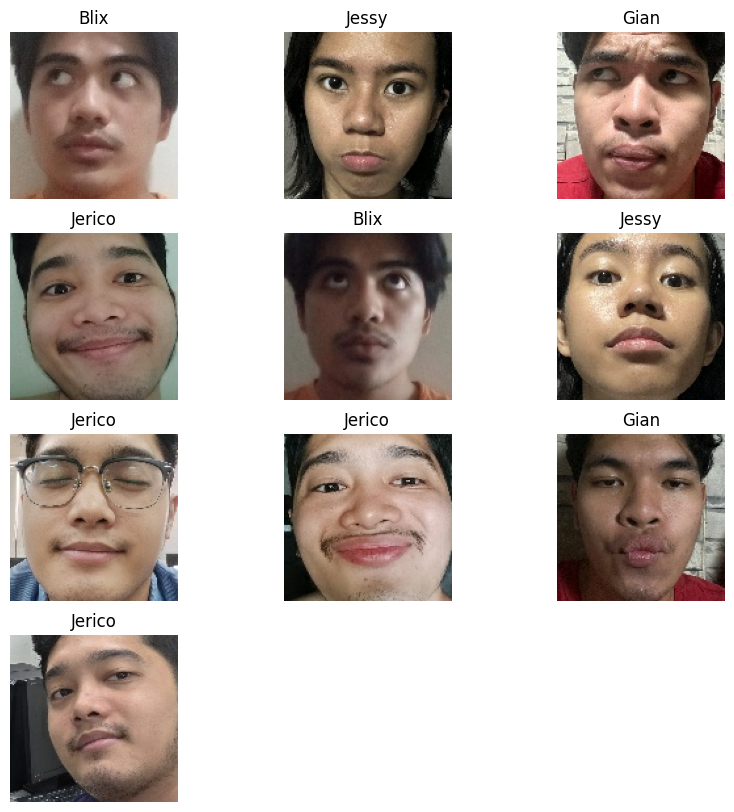

In [53]:
class_names = ["Blix", "Gian", "Jerico", "Jessy"]

plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    num_images = images.shape[0]
    for i in range(num_images):
        ax = plt.subplot(4, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [54]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3), include_top=False, weights='imagenet')
base_model.trainable = False

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.1),
])


In [55]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),
    # Increased units in dense layers
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(4, activation='softmax')  # 4 classes
])


In [56]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard

In [57]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=100,
    restore_best_weights=True,
    verbose=1,
    min_delta=0.0001,
    start_from_epoch=5
)
     

In [58]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

In [59]:
initial_learning_rate = 0.000005
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)


model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)


In [60]:
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 1000,
    callbacks = [early_stop, reduce_lr]
)


Epoch 1/1000
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 118ms/step - accuracy: 0.3522 - loss: 1.5956 - val_accuracy: 0.5610 - val_loss: 1.2482 - learning_rate: 0.0010
Epoch 2/1000
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.6210 - loss: 1.0111 - val_accuracy: 0.6098 - val_loss: 1.0400 - learning_rate: 0.0010
Epoch 3/1000
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.6502 - loss: 0.8442 - val_accuracy: 0.5732 - val_loss: 1.2175 - learning_rate: 0.0010
Epoch 4/1000
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.7477 - loss: 0.6772 - val_accuracy: 0.6220 - val_loss: 1.2154 - learning_rate: 0.0010
Epoch 5/1000
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.7444 - loss: 0.6478 - val_accuracy: 0.6341 - val_loss: 1.0387 - learning_rate: 0.0010
Epoch 6/1000
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.8183 - loss: 0.5044 - val_accuracy: 0.5488 - val_loss: 1.7852 - learning_rate: 0.0010
Epoch 7/1000
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.8095 - loss: 

In [44]:
model.evaluate(test_ds)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.7453 - loss: 0.6947


[0.7812520861625671, 0.7225806713104248]

In [46]:
def plot_history(history):
  fig, (ax1, ax2) = plt.subplots(2, figsize=(12, 12)) # Unpack into ax1 and ax2
  ax1.legend(['train', 'validation'], loc='upper left') # Call legend on ax1
  ax1.plot(history.history['loss']) # Plot on ax1
  ax1.plot(history.history['val_loss']) # Plot on ax1
  ax1.set_title('model loss') # Set title on ax1
  ax1.set_ylabel('loss') # Set label on ax1
  ax1.set_xlabel('epoch') # Set label on ax1
  ax2.legend(['train', 'validation'], loc='upper left') # Call legend on ax2
  ax2.plot(history.history['accuracy']) # Plot on ax2
  ax2.plot(history.history['val_accuracy']) # Plot on ax2
  ax2.set_title('model accuracy') # Set title on ax2
  ax2.set_ylabel('accuracy') # Set label on ax2
  ax2.set_xlabel('epoch') # Set label on ax2
  plt.show() # Show the plot

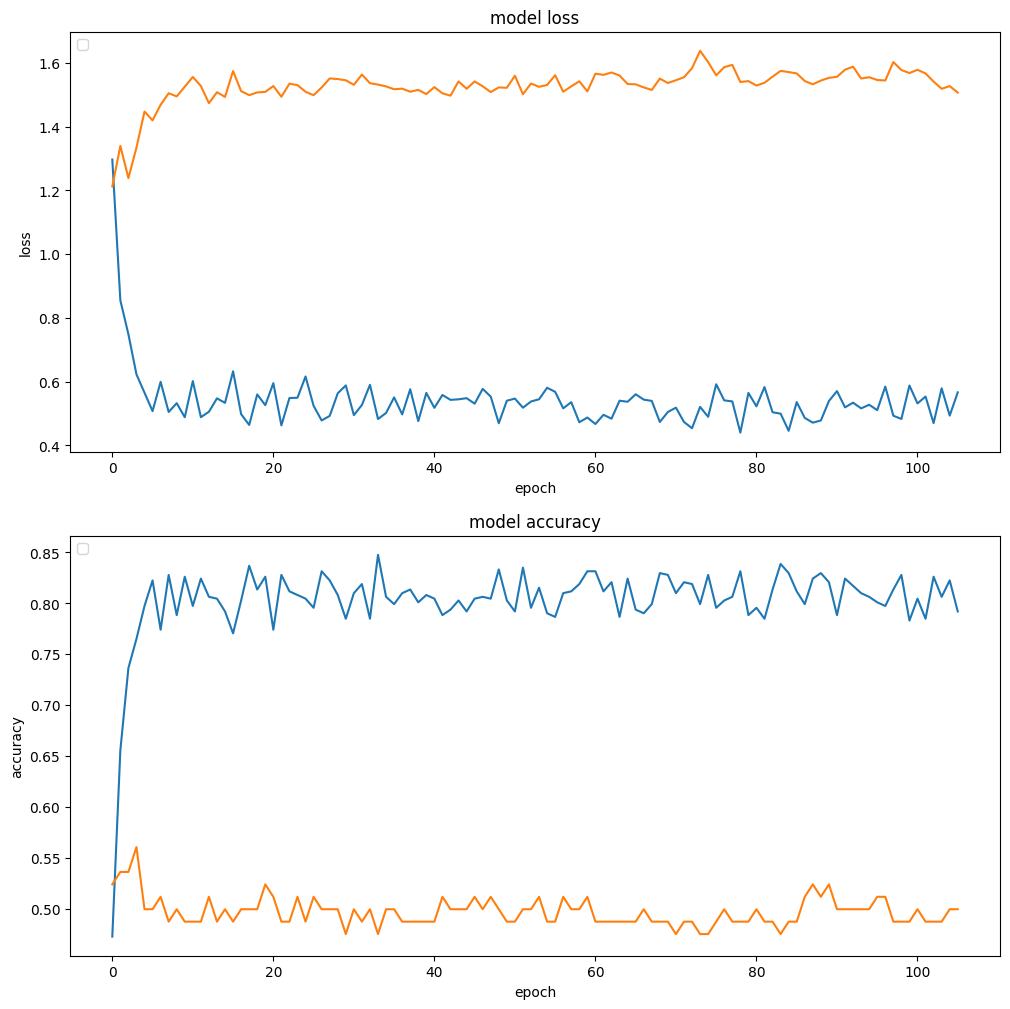

In [47]:
plot_history(history)

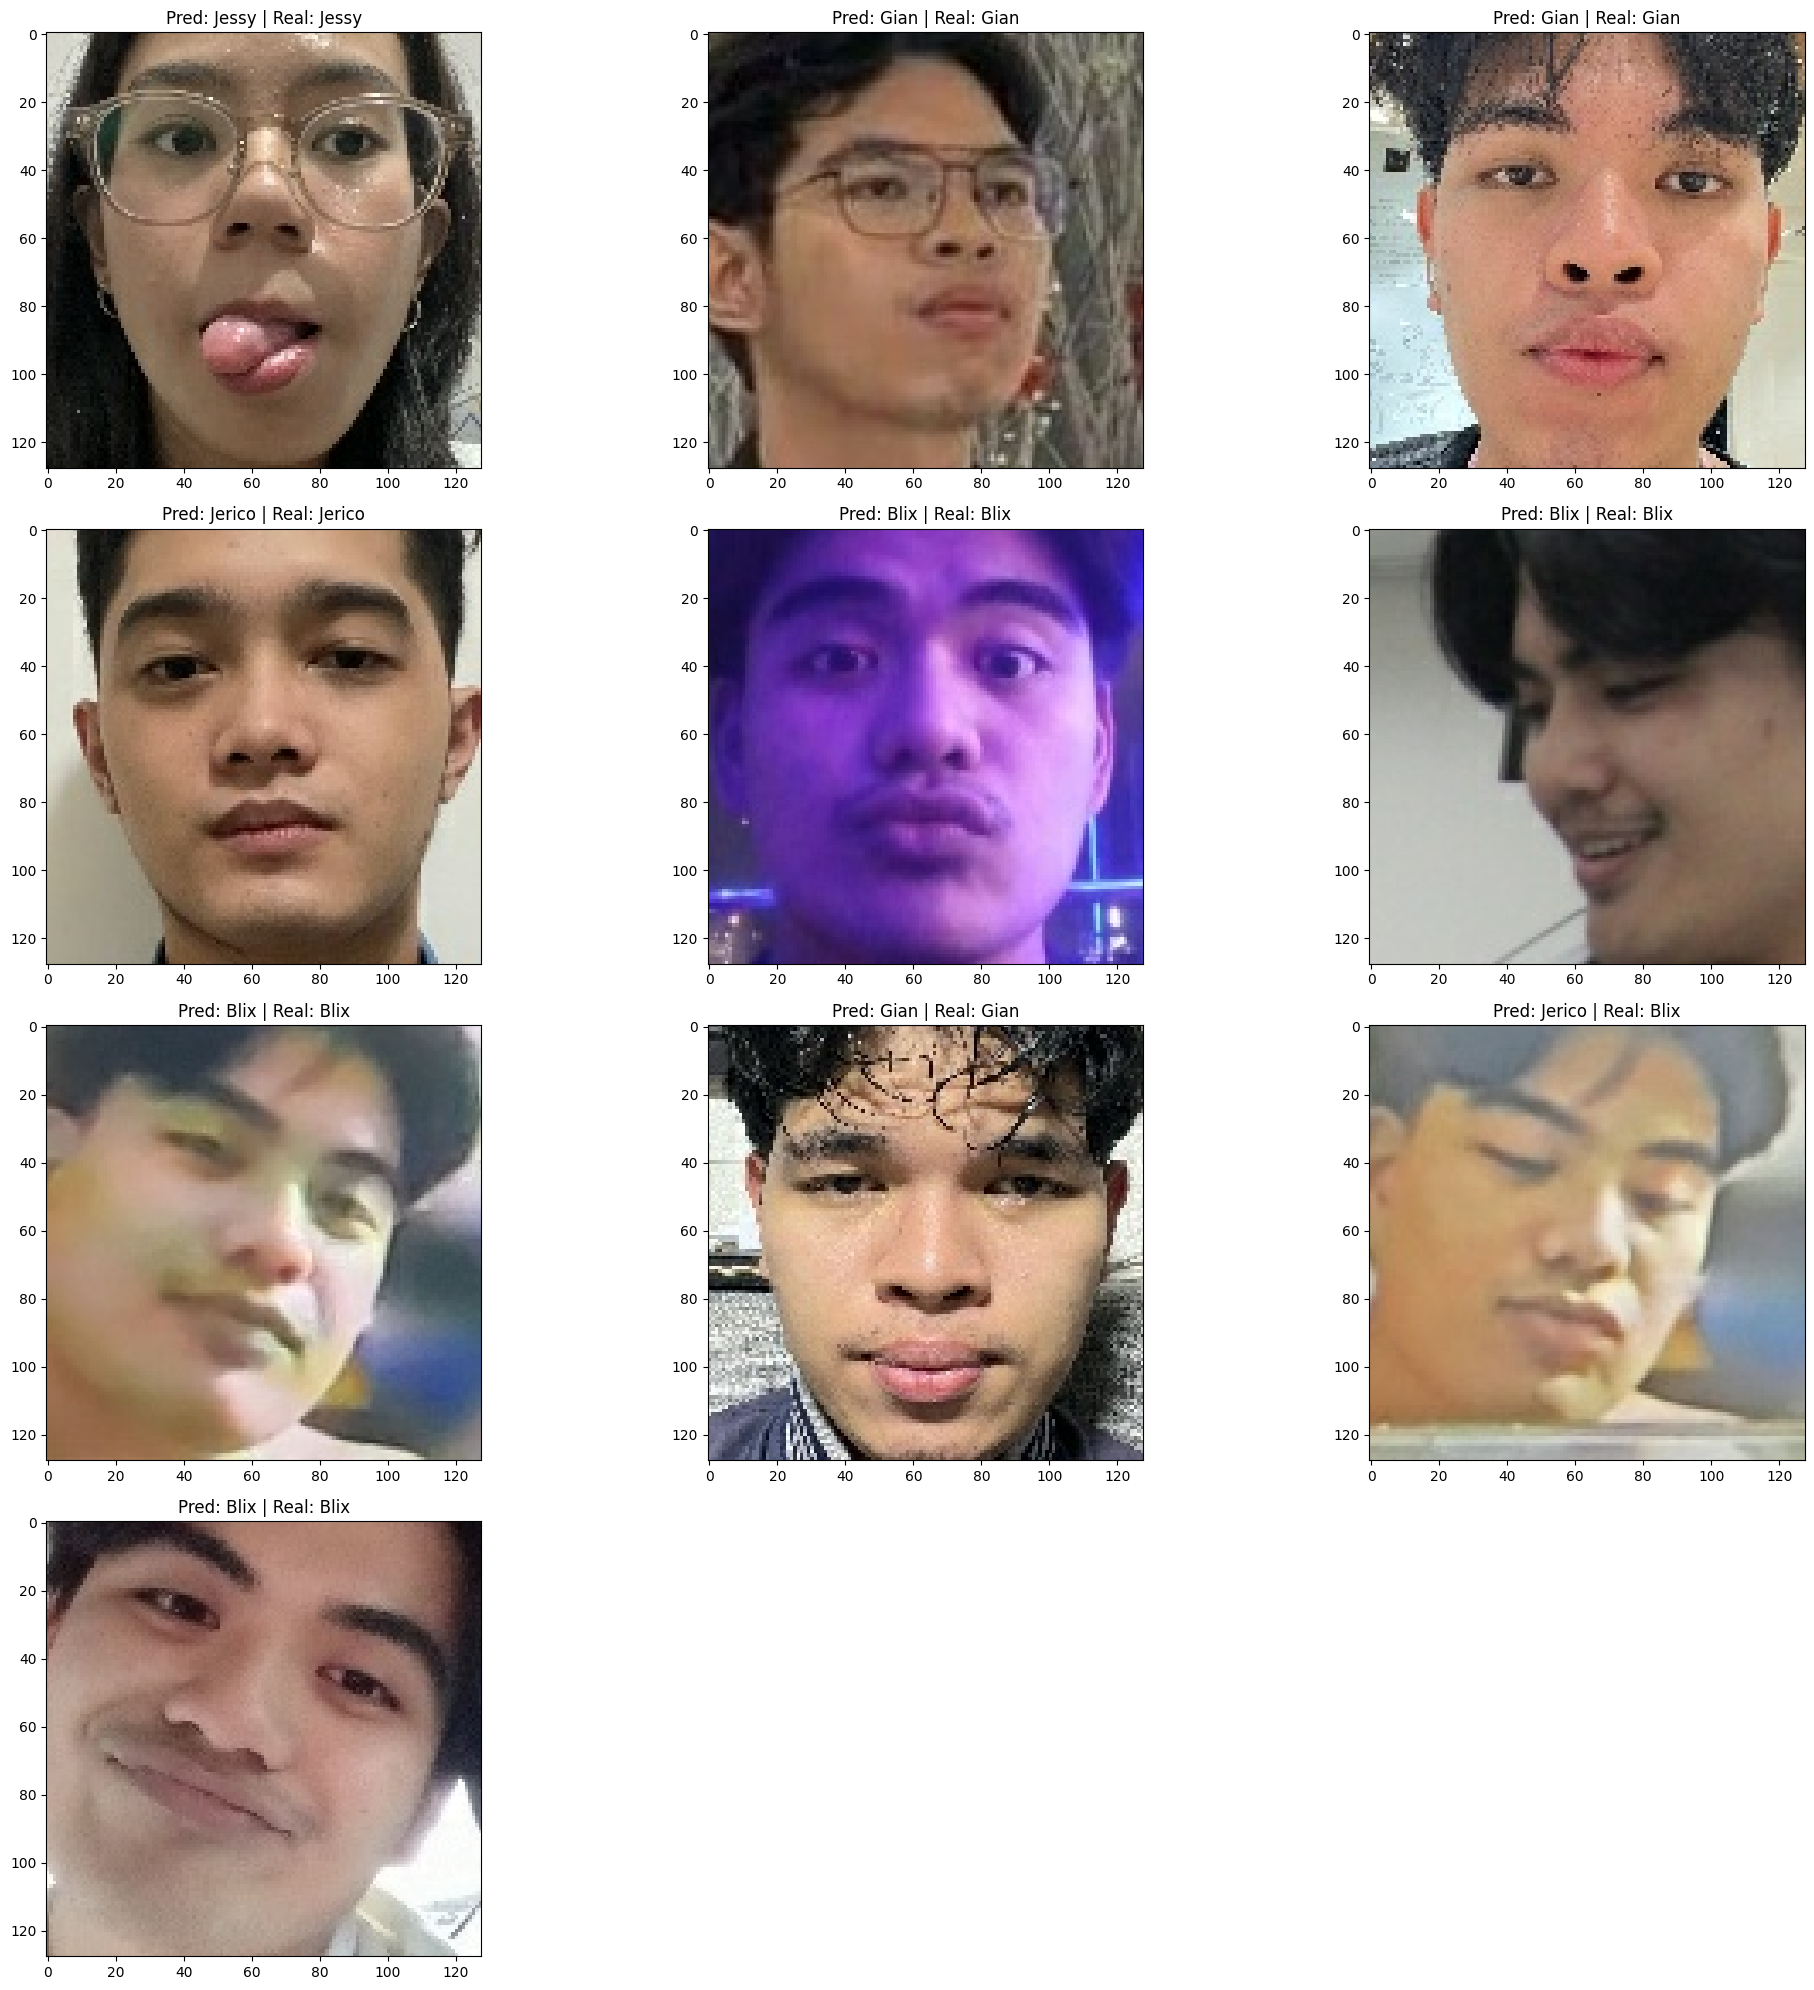

In [49]:
import numpy

plt.figure(figsize=(20,20))
for images, labels in test_ds.take(1):
    # Ensure images are the correct shape
    if images.shape[1:3] != (img_height, img_width):
        images = tf.image.resize(images, (img_height, img_width))
    # Preprocess images before prediction
    classifications = model.predict(images, verbose=0)
    num_images = images.shape[0]  # Get actual number of images in the batch
    for i in range(num_images):
        ax = plt.subplot(4, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        index = numpy.argmax(classifications[i])
        plt.title("Pred: " + class_names[index] + " | Real: " + class_names[labels[i]])
plt.tight_layout()